# 1.Contextualização


Este trabalho foi desenvolvido pela aluna Evelyn Klein (Turma 2026/1 - V2) como Projeto Final da Unidade Curricular "Modelagem de Dados" do programa SCTEC/SENAI para fins de avaliação e conclusão do Módulo 1 do Curso "Visualização de Dados e Business Intelligence".

Inicialmente, os dados foram consultados em um banco de dados SQL por meio de duas queries, responsáveis por extrair informações sobre funcionários, salários, departamentos e localização geográfica.

Em seguida, os dados passaram por etapas de exploração, análise estatística e visualização gráfica para identificação de padrões e geração de insights apresentadas neste notebook.

# 2.Objetivos



O principal objetivo deste projeto foi realizar uma Análise Exploratória de Dados (EDA) utilizando informações de funcionários de uma empresa. Para isso, buscou-se:

- extrair dados de um banco SQL utilizando consultas (queries);
- importar e manipular os dados no Python;
- realizar análises estatísticas descritivas;
- identificar padrões na distribuição dos salários;
- comparar a remuneração entre departamentos e regiões;
- identificar possíveis valores atípicos (outliers);
- apresentar os resultados por meio de gráficos e tabelas.

# 3.Metodologia

## 3.1 Banco de Dados e Consultas SQL





Foram utilizadas duas consultas SQL sobre a base de dados de Recursos Humanos (HR).

### 3.1.1 Query 1




A primeira consulta retornou informações sobre funcionários, incluindo identificação, cargo, departamento e salário.

Foram selecionadas as colunas EMPLOYEE_ID, FIRST_NAME, LAST_NAME, SALARY, JOB_TITLE e DEPARTMENT_NAME, permitindo analisar a distribuição salarial entre cargos e departamentos.

### 3.1.2 Query 2




A segunda consulta reuniu dados de localização, como cidade, país e região.

Foram selecionadas as colunas EMPLOYEE_ID, FIRST_NAME, LAST_NAME, DEPARTMENT_NAME, CITY, COUNTRY_NAME e REGION_NAME, possibilitando análises comparativas entre diferentes regiões geográficas.

### 3.1.3 Consultas SQL utilizadas

Ambas queries utilizaram LEFT JOIN para relacionar as tabelas necessárias, preservando os registros da tabela principal mesmo quando não havia correspondência em alguma tabela relacionada.

As duas bases foram posteriormente integradas utilizando a coluna EMPLOYEE_ID, permitindo relacionar informações salariais e geográficas.

Após a integração, obteve-se um conjunto com 106 registros, pois um funcionário presente na primeira base não possuía informações correspondentes na segunda.

Após a execução das consultas, os resultados foram exportados em arquivos CSV e importados para o repositório do GitHub pessoal da aluna-autora.

O código SQL completo das consultas encontra-se disponível no Apêndice A deste trabalho assim como na documentação do repositório do trabalho.

## 3.2 Importação das Bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para a análise dos dados.

O Pandas será utilizado para leitura e manipulação dos arquivos CSV, enquanto o Matplotlib será utilizado para a criação dos gráficos.

In [ ]:
from pathlib import Path

try:
    PROJECT_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()
    if (BASE_DIR / "data").exists():
        PROJECT_DIR = BASE_DIR
    elif (BASE_DIR.parent / "data").exists():
        PROJECT_DIR = BASE_DIR.parent
    else:
        PROJECT_DIR = BASE_DIR

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib
RUNNING_AS_SCRIPT = "__file__" in globals()
if RUNNING_AS_SCRIPT:
    matplotlib.use("Agg")

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
# Formata valores numericos com duas casas decimais no pandas.
pd.set_option("display.float_format", "{:,.2f}".format)


## 3.3 Carregamento dos CSVs

Nesta etapa são carregados os arquivos CSV gerados a partir das consultas SQL realizadas no banco de dados FreeSQL.

Os dados serão armazenados em DataFrames para permitir a análise exploratória.

In [ ]:
df1 = pd.read_csv(DATA_DIR / "query_01.csv")
df2 = pd.read_csv(DATA_DIR / "query_02.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'query_01.csv'

# 4.Análise Exploratória de Dados (EDA)

A presente Análise Exploratória de Dados (EDA) buscou compreender a estrutura da base, identificar possíveis inconsistências, calcular estatísticas descritivas e gerar visualizações que auxiliem na identificação de padrões, diferenças salariais e possíveis valores atípicos.

## 4.1 Verificação inicial dos dados
Nesta etapa foi realizada uma inspeção inicial dos dados para verificar se os arquivos CSV foram carregados corretamente.

Foram utilizadas as funções head(), info(), describe() e isnull().sum() para conhecer a estrutura dos dados, os tipos das variáveis, as estatísticas descritivas e a existência de valores ausentes.

In [ ]:
df1.head()

A visualização das primeiras linhas do conjunto de dados confirma que a Query 1 foi importada corretamente.

O conjunto contém informações de identificação dos funcionários, salário, cargo e departamento, que serão utilizadas nas análises estatísticas realizadas ao longo do estudo.

In [ ]:
df2.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,DEPARTMENT_NAME,CITY,COUNTRY_NAME,REGION_NAME
0,202,Pat,Davis,Marketing,Toronto,Canada,Americas
1,201,Michael,Martinez,Marketing,Toronto,Canada,Americas
2,206,William,Gietz,Accounting,Seattle,United States of America,Americas
3,205,Shelley,Higgins,Accounting,Seattle,United States of America,Americas
4,113,Luis,Popp,Finance,Seattle,United States of America,Americas


A visualização das primeiras linhas da Query 2 confirma que os dados também foram importados corretamente.

O segundo conjunto reúne informações sobre departamentos, cidades, países e regiões dos colaboradores, possibilitando análises relacionadas à distribuição geográfica dos funcionários.

## 4.2 Estrutura e Qualidade dos Dados
A função info() foi utilizada para verificar o tipo de cada coluna e a quantidade de registros presentes nos conjuntos de dados.

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EMPLOYEE_ID      107 non-null    int64 
 1   FIRST_NAME       107 non-null    object
 2   LAST_NAME        107 non-null    object
 3   SALARY           107 non-null    int64 
 4   JOB_TITLE        107 non-null    object
 5   DEPARTMENT_NAME  106 non-null    object
dtypes: int64(2), object(4)
memory usage: 5.1+ KB


A estrutura do conjunto de dados da Query 1 demonstra que os tipos das colunas são adequados para a análise.

O conjunto possui 107 registros e foi identificado apenas 1 valor ausente na coluna DEPARTMENT_NAME, não comprometendo a qualidade dos dados.

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EMPLOYEE_ID      106 non-null    int64 
 1   FIRST_NAME       106 non-null    object
 2   LAST_NAME        106 non-null    object
 3   DEPARTMENT_NAME  106 non-null    object
 4   CITY             106 non-null    object
 5   COUNTRY_NAME     106 non-null    object
 6   REGION_NAME      106 non-null    object
dtypes: int64(1), object(6)
memory usage: 5.9+ KB


A estrutura da Query 2 apresenta 106 registros, com todas as colunas preenchidas, sem valores ausentes.

Os tipos de dados são compatíveis com as análises propostas, permitindo comparações entre funcionários, departamentos e regiões.

## 4.3 Estatísticas Descritivas
A função describe() foi utilizada para obter medidas estatísticas como média, desvio padrão, valores mínimo e máximo, auxiliando na compreensão da distribuição dos dados.

In [ ]:
df1.describe()

,EMPLOYEE_ID,SALARY
count,107.00,107.00
mean,153.00,"6,461.83"
std,31.03,"3,909.58"
min,100.00,"2,100.00"
25%,126.50,"3,100.00"
50%,153.00,"6,200.00"
75%,179.50,"8,900.00"
max,206.00,"24,000.00"


As estatísticas descritivas mostram que o conjunto possui 107 registros.

A média salarial é de aproximadamente 6.462, enquanto a mediana é de 6.200, indicando uma distribuição relativamente equilibrada, mas com salários mais elevados influenciando a média.

O menor salário é de 2.100 e o maior é de 24.000, evidenciando uma ampla variação salarial entre os colaboradores.

In [ ]:
df2.describe(include="all")

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,DEPARTMENT_NAME,CITY,COUNTRY_NAME,REGION_NAME
count,106.00,106,106,106,106,106,106
unique,NaN,91,102,11,7,4,2
top,NaN,John,Taylor,Shipping,South San Francisco,United States of America,Americas
freq,NaN,3,2,45,45,68,70
mean,152.76,NaN,NaN,NaN,NaN,NaN,NaN
std,31.08,NaN,NaN,NaN,NaN,NaN,NaN
min,100.00,NaN,NaN,NaN,NaN,NaN,NaN
25%,126.25,NaN,NaN,NaN,NaN,NaN,NaN
50%,152.50,NaN,NaN,NaN,NaN,NaN,NaN
75%,179.75,NaN,NaN,NaN,NaN,NaN,NaN


Observa-se que o conjunto possui 106 registros, com predominância do departamento Shipping, da cidade South San Francisco, do país United States of  (Estados Unidos da América) e da região Americas.

O conjunto apresenta boa diversidade principalmente de localidades, fornecendo uma visão geral da distribuição dos dados antes das análises mais detalhadas.

## 4.4 Verificação de valores ausentes
Foi realizada a verificação de valores ausentes utilizando isnull().sum().

In [ ]:
df1.isnull().sum()

,0
EMPLOYEE_ID,0
FIRST_NAME,0
LAST_NAME,0
SALARY,0
JOB_TITLE,0
DEPARTMENT_NAME,1


In [ ]:
df2.isnull().sum()

,0
EMPLOYEE_ID,0
FIRST_NAME,0
LAST_NAME,0
DEPARTMENT_NAME,0
CITY,0
COUNTRY_NAME,0
REGION_NAME,0


O conjunto df1 apresentou apenas 1 valor nulo na coluna DEPARTMENT_NAME, enquanto o df2 não apresentou valores ausentes.

Como a quantidade de dados faltantes é insignificante, não foi necessário realizar tratamento adicional.

A etapa de Análise Exploratória de Dados permitiu compreender a estrutura dos conjuntos de dados, verificar a qualidade das informações e confirmar que os dados estavam adequados para as análises propostas.

Após essa validação, é possível dar continuidade nas análises específicas.

# 5.Análise da Distribuição Salarial

## 5.1 Estatísticas dos salários

Nesta etapa são calculadas medidas estatísticas para compreender a distribuição dos salários dos colaboradores.

In [ ]:
print(f"Media: {df1['SALARY'].mean():.2f}")
print(f"Mediana: {df1['SALARY'].median():.2f}")
print(f"Minimo: {df1['SALARY'].min():.2f}")
print(f"Maximo: {df1['SALARY'].max():.2f}")


Média: 6461.8317757009345
Mediana: 6200.0
Mínimo: 2100
Máximo: 24000


Os resultados indicam salário médio de aproximadamente 6.462, mediana de 6.200, salário mínimo de 2.100 e salário máximo de 24.000, demonstrando uma ampla variação salarial entre os colaboradores.

## 5.2 Histograma de salários

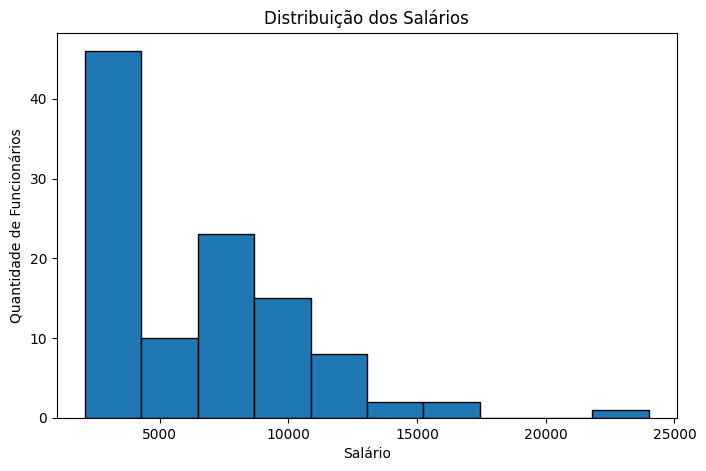

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df1["SALARY"], bins=10, edgecolor="black", color="#4C78A8")
plt.title("Distribuicao dos salarios")
plt.xlabel("Salario")
plt.ylabel("Quantidade de funcionarios")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "histograma_salarios.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()


O histograma mostra que a maior parte dos colaboradores está concentrada nas faixas salariais mais baixas e intermediárias.

Poucos funcionários recebem salários muito elevados, o que ajuda a explicar a diferença entre média e mediana e reforça a presença de valores extremos na base.

## 5.3 Média salarial por departamento

A seguir é apresentada a média salarial dos colaboradores em cada departamento, permitindo identificar diferenças entre os setores da empresa.

In [ ]:
df1.groupby("DEPARTMENT_NAME")["SALARY"].mean().sort_values(ascending=False)

,SALARY
DEPARTMENT_NAME,
Executive,"19,333.33"
Accounting,"10,154.00"
Public Relations,"10,000.00"
Marketing,"9,500.00"
Sales,"8,955.88"
Finance,"8,601.33"
Human Resources,"6,500.00"
IT,"5,760.00"
Administration,"4,400.00"


A média salarial por departamento mostra que o setor Executive possui a maior remuneração média (19.333,33), enquanto o departamento Shipping apresenta a menor média salarial (3.475,56).


## 5.4 Top 10 cargos com maior média salarial

In [ ]:
media_cargo = (
    df1.groupby("JOB_TITLE")["SALARY"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
media_cargo

,SALARY
JOB_TITLE,
President,"24,000.00"
Administration Vice President,"17,000.00"
Marketing Manager,"13,000.00"
Sales Manager,"12,200.00"
Finance Manager,"12,008.00"
Accounting Manager,"12,008.00"
Purchasing Manager,"11,000.00"
Public Relations Representative,"10,000.00"
Sales Representative,"8,350.00"


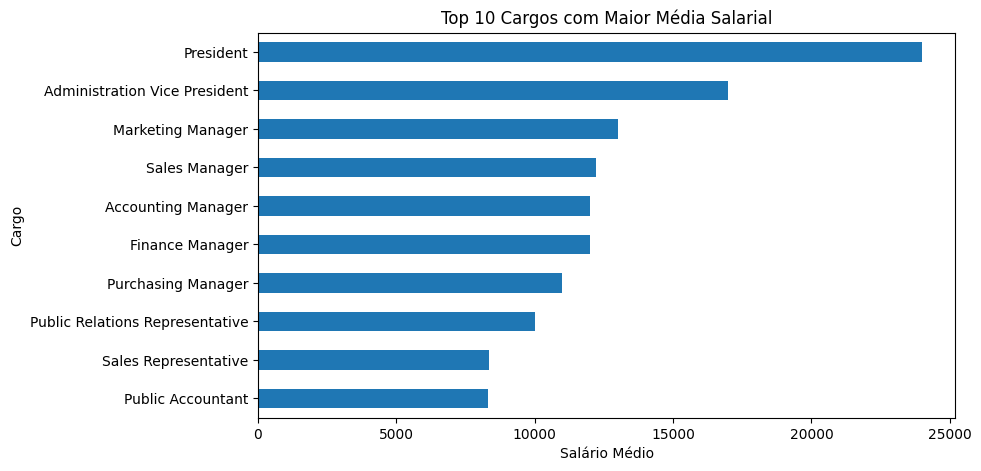

In [ ]:
media_cargo.sort_values().plot(kind="barh", figsize=(9,5), color="#F58518")
plt.title("Top 10 Cargos com Maior Media Salarial")
plt.xlabel("Salario Medio")
plt.ylabel("Cargo")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_10_cargos_maior_media_salarial.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()


A análise por cargo permite identificar quais funções concentram as maiores remunerações médias.

Esse olhar complementa a análise por departamento, pois mostra que a diferença salarial não depende apenas do setor, mas também do nível de responsabilidade associado a cada cargo.

## 5.5 Boxplot do salário por departamento

<Figure size 1200x600 with 0 Axes>

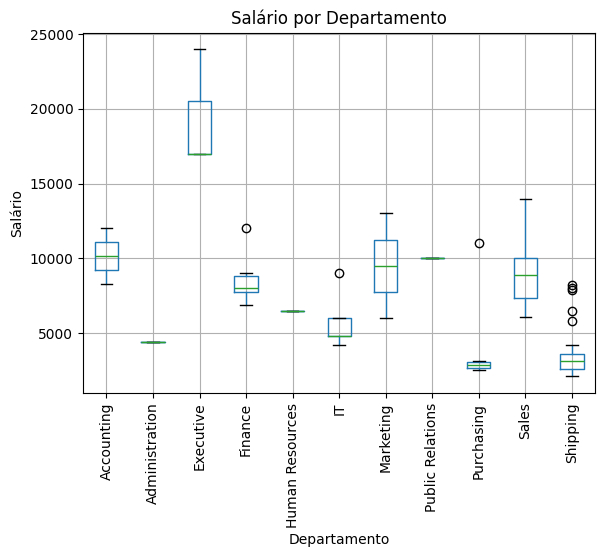

In [ ]:
plt.figure(figsize=(12,6))
df1.boxplot(column="SALARY", by="DEPARTMENT_NAME", rot=90)
plt.title("Salario por Departamento")
plt.suptitle("")
plt.xlabel("Departamento")
plt.ylabel("Salario")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "boxplot_salario_por_departamento.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()


O boxplot permite visualizar a distribuição dos salários em cada departamento, destacando a mediana, a variação dos valores e possíveis outliers.

Observa-se que o departamento Executive possui os maiores salários, enquanto departamentos como Shipping, Purchasing e Administration apresentam médias salariais mais baixas.

Além disso, alguns departamentos apresentam maior dispersão salarial, indicando diferenças na remuneração entre os colaboradores.

## 5.6 Salário Médio por Cargo (Horizontal)

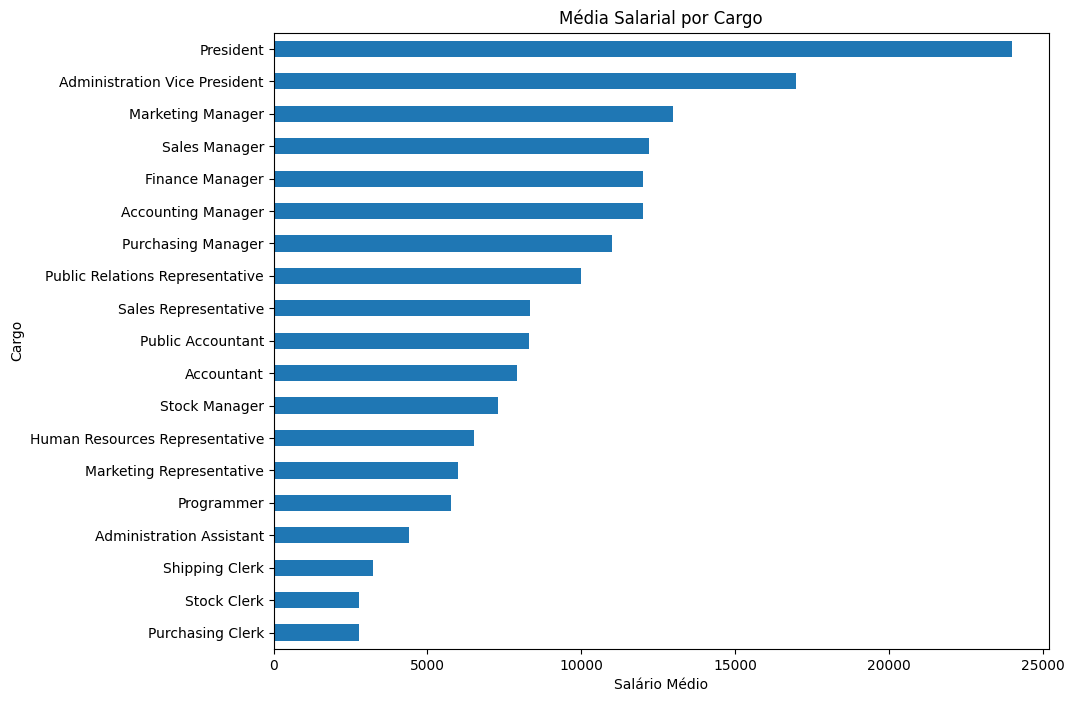

In [ ]:
cargo = (
    df1.groupby("JOB_TITLE")["SALARY"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(10,8))
cargo.plot(kind="barh", color="#54A24B")
plt.title("Media Salarial por Cargo")
plt.xlabel("Salario Medio")
plt.ylabel("Cargo")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "media_salarial_por_cargo.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()


# 6.Análise Geográfica

## 6.1 Integração dos Dados

In [ ]:
print("Query 1:", df1.shape)
print("Query 2:", df2.shape)


(106, 7)

## 6.2 Média salarial por região

Como a região está no df2, vamos juntar os dois DataFrames.

In [ ]:
df = pd.merge(
    df1,
    df2[["EMPLOYEE_ID", "REGION_NAME"]],
    on="EMPLOYEE_ID",
    how="left"
)


In [ ]:
df.shape

(106, 7)

In [ ]:
df1.shape, df2.shape, df.shape

((107, 6), (106, 7), (106, 7))

A junção entre as bases resultou em 106 registros, enquanto a Query 1 possui 107 registros.

Isso indica que um funcionário presente na base salarial não possuía correspondência na base geográfica.

Dessa forma, as análises por região foram realizadas apenas com os registros que tinham informações completas de localização.

In [ ]:
df.groupby("REGION_NAME")["SALARY"].mean()

,SALARY
REGION_NAME,
Americas,"5,191.66"
Europe,"8,916.67"


Após a junção dos DataFrames, foi calculada a média salarial por região.

Os resultados mostram que a região Europe possui a maior média salarial (R$8.916,67), enquanto a região Americas apresenta média de aproximadamente 5.192, evidenciando diferenças de remuneração entre as regiões analisadas.

## 6.3 Gráfico da média salarial por região

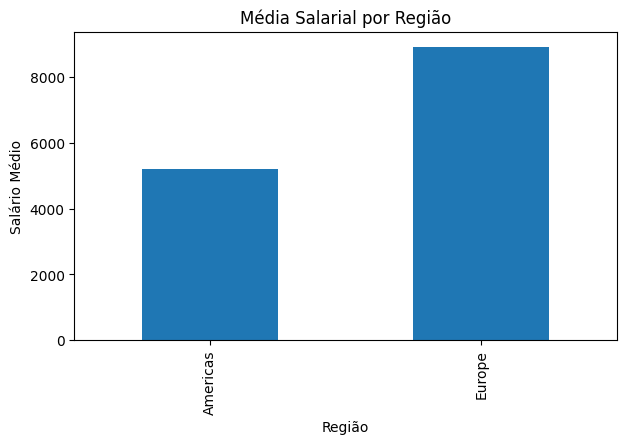

In [ ]:
df.groupby("REGION_NAME")["SALARY"].mean().plot(
    kind="bar",
    figsize=(7,4),
    color="#E45756"
)
plt.title("Media Salarial por Regiao")
plt.xlabel("Regiao")
plt.ylabel("Salario Medio")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "media_salarial_por_regiao.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()


Observa-se que a região Europe apresenta a maior média salarial (8.916,67), enquanto a região Americas possui média de aproximadamente 5.192, demonstrando diferenças na remuneração média entre as regiões.

## 6.4 Quantidade de Funcionários por Região

# 7.Análises Adicionais

Além das análises solicitadas na proposta do projeto, foram realizadas análises complementares com o objetivo de aprofundar a compreensão da distribuição dos dados e identificar novos padrões relacionados à estrutura salarial e à distribuição dos colaboradores na empresa.

## 7.1 Quantidade de funcionários por departamento

In [ ]:
func_por_depto = df1["DEPARTMENT_NAME"].value_counts()
func_por_depto

,count
DEPARTMENT_NAME,
Shipping,45
Sales,34
Finance,6
Purchasing,6
IT,5
Executive,3
Marketing,2
Accounting,2
Public Relations,1


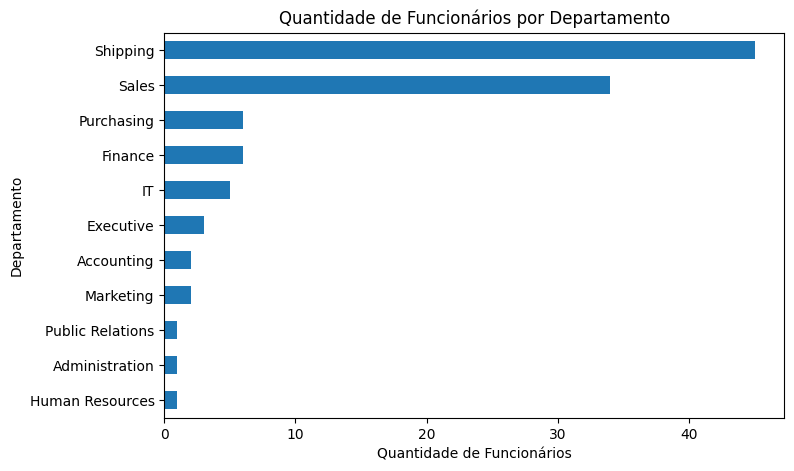

In [ ]:
func_por_depto.sort_values().plot(kind="barh", figsize=(8,5), color="#72B7B2")
plt.title("Quantidade de Funcionarios por Departamento")
plt.xlabel("Quantidade de Funcionarios")
plt.ylabel("Departamento")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "quantidade_funcionarios_por_departamento.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()


Essa informação é importante porque departamentos com maior número de colaboradores podem impactar mais fortemente a média geral da empresa, enquanto setores menores podem apresentar médias mais sensíveis a poucos salários altos ou baixos.

## 7.2 Média salarial x quantidade de funcionários por departamento

In [ ]:
resumo_departamento = df1.groupby("DEPARTMENT_NAME").agg(
    MEDIA_SALARIAL=("SALARY", "mean"),
    QTD_FUNCIONARIOS=("EMPLOYEE_ID", "count")
).sort_values("MEDIA_SALARIAL", ascending=False)
resumo_departamento

,MEDIA_SALARIAL,QTD_FUNCIONARIOS
DEPARTMENT_NAME,,
Executive,"19,333.33",3
Accounting,"10,154.00",2
Public Relations,"10,000.00",1
Marketing,"9,500.00",2
Sales,"8,955.88",34
Finance,"8,601.33",6
Human Resources,"6,500.00",1
IT,"5,760.00",5
Administration,"4,400.00",1


É possível observar se os departamentos com maiores salários médios também possuem muitos colaboradores ou se são setores menores, compostos por cargos mais estratégicos.

## 7.3 Faixas Salariais

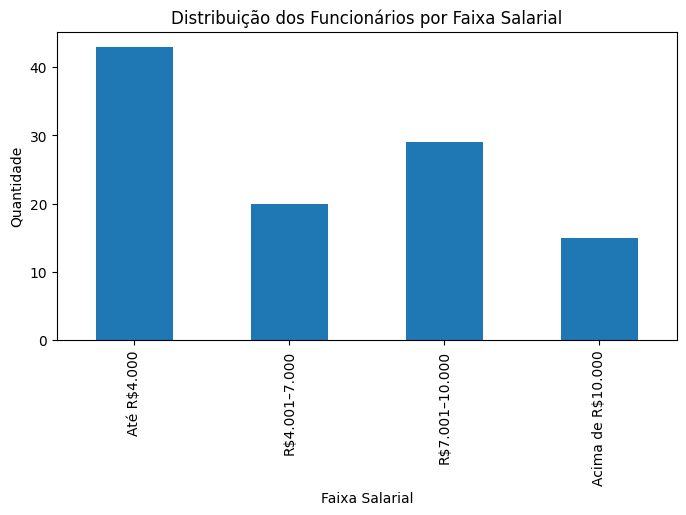

In [ ]:
faixas = pd.cut(
    df1["SALARY"],
    bins=[0,4000,7000,10000,25000],
    labels=[
        "Ate R$4.000",
        "R$4.001-7.000",
        "R$7.001-10.000",
        "Acima de R$10.000"
    ]
)
faixas.value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,4),
    color="#B279A2"
)
plt.title("Distribuicao dos Funcionarios por Faixa Salarial")
plt.xlabel("Faixa Salarial")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribuicao_por_faixa_salarial.png", dpi=150, bbox_inches="tight")
if not RUNNING_AS_SCRIPT:
    plt.show()
plt.close()


A maior parte dos colaboradores concentra-se nas faixas salariais intermediárias, enquanto poucos funcionários recebem salários acima de 10.000.


# 8.Identificação de Outliers

Esta etapa identifica quais funcionários possuem salários considerados fora do padrão estatístico através do método do Intervalo Interquartil (IQR).



In [ ]:
Q1 = df1["SALARY"].quantile(0.25)
Q3 = df1["SALARY"].quantile(0.75)
IQR = Q3 - Q1
outliers = df1[
    (df1["SALARY"] < Q1 - 1.5 * IQR) |
    (df1["SALARY"] > Q3 + 1.5 * IQR)
]
outliers

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,JOB_TITLE,DEPARTMENT_NAME
0,100,Steven,King,24000,President,Executive


Foi identificado 1 funcionário com salário acima do padrão estatístico do conjunto de dados, pertencente ao departamento Executive.

Esse valor representa uma remuneração significativamente superior à maior parte dos salários analisados, justificando sua classificação como outlier.

# 9.Principais Insights

- O departamento Executive possui a maior remuneração média da empresa, indicando concentração de cargos estratégicos.


- Shipping é o departamento com menor média salarial e também um dos que possuem maior número de colaboradores.

- A Europa apresentou média salarial superior à região Americas para os funcionários presentes na base analisada.

- Apenas um salário foi considerado outlier, indicando que a distribuição salarial é relativamente consistente.

# 10.Limitações da Análise

A análise foi realizada com base em duas consultas SQL extraídas do banco de dados HR. Algumas informações presentes na base original não foram utilizadas, pois não faziam parte do escopo do projeto.

Além disso, um funcionário da base salarial não possuía informações de localização, motivo pelo qual a análise geográfica considerou 106 registros após a integração das bases.

#11.Conclusão



A análise permitiu compreender a estrutura salarial dos colaboradores a partir de duas perspectivas principais: departamentos e regiões.

Os resultados mostraram que o departamento Executive concentra as maiores remunerações, enquanto Shipping apresenta a menor média salarial.

Também foi observado que a região Europe possui média salarial superior à região Americas, considerando os registros com informações geográficas disponíveis.

A EDA também revelou que a maior parte dos salários está concentrada em faixas mais baixas e intermediárias, enquanto poucos colaboradores possuem remunerações muito elevadas. Esse comportamento foi confirmado pela identificação de um outlier, pertencente ao departamento Executive, indicando um salário significativamente acima do padrão geral.

As queries foram essenciais para organizar os dados em duas bases complementares: uma voltada à análise salarial e outra à análise geográfica. A junção dessas bases permitiu ampliar a análise e gerar insights mais completos sobre a distribuição de salários na empresa.

Para análises futuras, seria interessante avaliar salários por cargo, comparar remuneração entre países e cidades, verificar a proporção de funcionários por departamento e criar faixas salariais para apoiar decisões relacionadas à contratação de novos colaboradores.

# 12.Apêndice A – Consultas SQL Utilizadas

As consultas SQL nos campos abaixo foram utilizadas para extrair os dados do banco HR, posteriormente exportados em formato CSV para a realização da Análise Exploratória de Dados (EDA).

Encontram-se disponibilizados no repositório GitHub pessoal da aluna-autora os arquivos consultas.sql, contendo as consultas completas, e os arquivos query1.csv e query2.csv, que correspondem aos conjuntos de dados utilizados no presente notebook.

In [ ]:
"""
# QUERY 1: Funcionários, cargos e departamentos
SELECT
    e.employee_id,
    e.first_name,
    e.last_name,
    e.salary,
    j.job_title,
    d.department_name
FROM hr.employees e
LEFT JOIN hr.jobs j
    ON e.job_id = j.job_id
LEFT JOIN hr.departments d
    ON e.department_id = d.department_id
WHERE e.salary IS NOT NULL
ORDER BY e.salary DESC;
"""


SyntaxError: invalid syntax (2410586456.py, line 1)

In [ ]:
"""
# QUERY 2: Funcionários, departamentos e localização
SELECT
    e.employee_id,
    e.first_name,
    e.last_name,
    d.department_name,
    l.city,
    c.country_name,
    r.region_name
FROM hr.employees e
LEFT JOIN hr.departments d
    ON e.department_id = d.department_id
LEFT JOIN hr.locations l
    ON d.location_id = l.location_id
LEFT JOIN hr.countries c
    ON l.country_id = c.country_id
LEFT JOIN hr.regions r
    ON c.region_id = r.region_id
WHERE d.department_name IS NOT NULL
ORDER BY r.region_name, c.country_name, l.city;
"""
